<a href="https://colab.research.google.com/github/christianlee479/CPSC-2200/blob/main/Copy_of_CPSC_2200_Assignment_2_Christian_Lee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Yale University


# CPSC 2200 Introduction to Data Analysis and Machine Learning for Humanities and Social Sciences

**Instructor**: Sohee Park

Department of Computer Science

### Assignment #2

**Post date:** February 18, 2026

**Due date:** March 3, 2026

Type your name, email, and NetID below (Double click the text cell below to enter texts).

### Your Name: Christian Lee
### Your Email: christian.lee@yale.edu
### NetID: cl2568

## Hide AI Assistance

**Collaboration with ChatGPT or other AI composition software is not permitted in this course.**

Go to `Tools` > `Settings` > `AI Assistance` menu, and hide generative AI features.
* Unselect `Show AI-Powered inline completion`.
* Select `Hide generative AI Features`,

<img src = 'https://drive.google.com/uc?id=1JgX2yYhFkgX6Y2EKKwVaTrJbuULJMYI5' />


## How to use this file?

* To work with the Colab files in this course, you will need to make your own copies of them. Go to the **File** menu and choose **Save a copy in Drive**.

* The files will be saved in a folder in your Google Drive called **Colab Notebooks**, which you can then move to a different folder, if you like.

* Rename the file by replacing "yourname" with **your first and last name**.

* Go to the **File** Menu and choose **Save** occasionally to save your work. (Shortcut key: `Ctrl + S` or `Command + S`)

* After completing the assignment, go to the **File** menu, choose **Download** --> **Download .ipynb** and download this .ipynb file to your local machine.

* Submit it to the GradeScope under Assignment #1.

## Academic Integrity

The homework assignments in this course are intended to give you practice at working through problems independently. Therefore, unless otherwise specified, the homework assignments are your individual responsibility and are not group assignments. Plagiarism is a violation of University rules and will not be tolerated. You must neither copy work from others (at Yale or elsewhere) nor allow your own work to be copied.

In addition to grade penalties, additional consequencesLinks to an external site. for breaking this policy may be imposed by the Yale College Executive Committee. Note that Gradescope will automatically check your submissions for code similarity with your peers and past submissions to similar assignments.

**You may:**

Ask others or search online for help with general issues with programming languages, APIs, IDEs, tools, and high-level course concepts that are not specific to the assignment.
Ask clarifying questions about the requirements of an assignment to TFs/ULAs or on the course discussion board.
Discuss more specific issues on an assignment with TFs/ULAs or the instructor.

**You may not:**
* Discuss your individual solution with your peers.
* Receive a printed or electronic copy of anyone else's work for the course from this term or any other term. * This includes asking or paying someone else to complete the assignment for you.
* Give anyone else a printed or electronic copy of your work for the course for this term or any other term. This includes posting your work publicly on sites such as Github.
* Seek out solutions to similar assignments online.
* Collaborate with ChatGPT or other AI composition software:  Collaboration with ChatGPT or other AI-based composition tools is **not permitted** in this course. Any assignment found to violate this policy will receive a grade of **0 for the assignment.**

If you have any questions about this policy or are unsure if you may have crossed a line, discuss it with the instructor as soon as possible.

**I certify that I have read and understand the Academic Integrity Policy. This submission is my own work, and I have not violated the Academic Integrity Policy.**

**Signature**: CHRISTIAN LEE

## To use GPU/TPU

* Go to the **Runtime** menu in Colab
* Select the  **Change Runtime type** menu
* Select **GPU** or **TPU** option

## Keras Installation and Setup

In [1]:
!pip install keras keras-hub==0.21.1 --upgrade -q   # keras-hub version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.0 MB/s eta 0:00:00


In [2]:
# @title
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Keras Installation and Setup

In [3]:
!pip install keras keras-hub==0.21.1 --upgrade -q   # keras-hub version

In [4]:
# @title
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

##Part 1: Image Classification ith CIFAR-10
**(1) Explain why CIFAR-10 is a multiclass classification problem rather than a multilabel classification problem.**

*CIFAR-10 is a multiclass classification problem because it enables each image to be assigned to exactly ONE LABEL from a FIXED SET OF 10 CLASSES. For example, if you have 10 pre-defined classes (dog, cat, horse, airplane, computer, television, bird, automobile, bike, and truck), CIFAR-10 will assign the image directly to and exclusively to one of these classes. These labels are MUTUALLY EXCLUSIVE unlike in a multiclass problem where an image can be correctly labeled ["dog", "cat", "horse"] at the same time.*

**(2) Why is the softmax activation function appropriate for the output layer in CIFAR-10 classification?**

*A softmax activation function is appropriate for CIFAR-10 because it converts the 10 RAW SCORES (one per class) into PROBABILITIES between 0 and 1. In English, this means that the model estimates how likely the image is to be in each class. For example, if you attempt to assign a label to an image of a cat, the model might determine an 0.85 probability to the "cat" class, 0.08 to the "dog" class, 0.01 to the "airplane" class, etc.*

**(3) Compare convolutional neural networks (CNNs) with fully connected neural networks for image classification. Why are CNNs preferred?**

*CNNs use the structure/dimensions of images (height, width, local patterns) in a much more efficient manner. These models use CONVOLUTIONS, or small filters, that slide across the image to look for local patterns such as edges, corners, and textures. This filter is reused across every part of the image (PARAMETER SHARING) which drastically reduces the number of parameters and allows them to detect the same feature anywhere in the image; and therefore, uses much less computational energy. In terms of its architecture, CNNs are able to PRESERVE SPACIAL STRUCTURE so that models can learn hierarchical features. Early layers might detect simple edges, middle layers may then detect shapes/parts, and later layers will then detect objects -- in practice, this makes it much more scalable to larger images than fully connected nets. With a fully connected neural network, images are treated like a 2D VECTOR OF PIXEL VALUES. Each neuron is assigned to a pixel. This means that in a 1920x1080 image, you'll need roughly 2 million parameters. With that many parameters, models can be computationally expensive, slow, and overfit without even being able to contextualize pixels by proximity and without understanding that visual features can appear anywhere in the image. Full-connected neural networks are not only unnecessarily expensive, you might not even get an an optimal output.*

**(4) Explain how convolutional layers and max pooling layers help reduce overfitting.**

*Convolutional layers reduce overfitting by utilizing LOCAL CONNECTIONS and PARAMETER SHARING: basically each neuron looks at a patch of the image(not every pixel) and uses a sliding filter across the image. This reduces the total number of parameters and cuts down the number of weights assigned to each neuron. With less parameters, there is inevitably less capacity to simply MEMORIZE the trainng set, leading to lower overfitting risk. Max pooling layers help by DOWNSAMPLING the feature maps(makes them smaller) and by keeping only the strongest activations in a region (feature hierarchy). Again, this allows for less overfitting because it reduces later computation & parameters, and makes features more up for interpretation, IMPROVING GENERALIZATION.*

**(5) What is the role of the ReLU activation function in CNNs?**

*ReLU, as a non-linear activation function, allows the network to learn complex patterns by outputting the VALUE if POSITIVE and 0 if the VALUE is NEGATIVE. Why not sigmoid or tanh, which also introduce non-linearity? Sigmoid is more fit for binary classification and has parity with probability problems and tanh can be computationally expensive; most importantly, both cause VANISHED GRADIENT problems where values are squashed,weight updates become extremely small during backpropagation, and there is no progressive learning. ReLU works because it doesn't condense output values between 0/-1 and 1, lowering risk of the "vanished gradient problem" and making learning more stable/effective for deeper networks. Without ReLU, stacking convolutionary layers would inevitably behave like a one large linear transformation, which is restrictive for image recognition. ReLU's also fairly simple, fast, inexpensive, promoting sparse activations since many neurons may be turned off for a given image given negative values.*

**(6) Why must images be normalized before training a neural network?**

*Normalizing images helps neural networks train faster and more effectively, like really any other form of data. It keeps raw pixel values that can be as large as 255 (input values) on a manageable scale, mitigating large activations and unstable gradients during training. A simple example of normalizing would be dividing the input by 255. Gradient descent works better since features are now on a more comparative scale, which means navigating the loss surface for optimizers becomes easier. As a product, weight updates become more consistent, and faster training is achieved.*








## Data Preparation
Load the CIFAR-10 dataset and normalize images  (You can use keras.datasets.cifar10.load_data() )


In [5]:
#Load the CIFAR-10 dataset (You can use keras.datasets.cifar10.load_data())
import keras
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

#Normalize images
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


## Build a CNN Classifier

Construct 2-3 Conv2D layers with MaxPooling2D layers
Output layer: Dense with 10 neurons + softmax activation.
Compile the model with sparse_categorical_crossentropy.
Train for 10–15 epochs, batch size = 64, use 20% of training data for validation.
Use ModelCheckpoint to save the best model.


In [6]:
from keras import layers
from keras.callbacks import ModelCheckpoint

# Use ModelCheckpoint to save the best model
checkpoint_filepath = 'best_model.keras'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

#Construct 2-3 Conv2D layers with MaxPooling2D layers
#Output layer: Dense with 10 neurons + softmax activation.
model = keras.Sequential(
    [
        keras.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5), #Dropout for regularization
        layers.Dense(10, activation="softmax"),
    ]
)

#Compile the model with sparse_categorical_crossentropy.
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Display model summary
model.summary()


#Train for 10–15 epochs, batch size = 64, use 20% of training data for validation.
history = model.fit(x_train, y_train,
            epochs=10,
            batch_size=64,
            validation_split=0.2,
            callbacks=[model_checkpoint_callback]
            )

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        23,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,442 (165.79 KB)

 Trainable params: 42,442 (165.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3873 - loss: 1.6997 - val_accuracy: 0.5128 - val_loss: 1.4009
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5089 - loss: 1.3887 - val_accuracy: 0.5549 - val_loss: 1.2934
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5471 - loss: 1.2906 - val_accuracy: 0.5904 - val_loss: 1.1980
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5724 - loss: 1.2188 - val_accuracy: 0.6073 - val_loss: 1.1404
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5924 - loss: 1.1752 - val_accuracy: 0.6248 - val_loss: 1.1002
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6097 - loss: 1.1277 - val_accuracy: 0.6353 - val_loss: 1.0638
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6191 - loss: 1.1015 - val_accuracy: 0.6376 - val_loss: 1.0601
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6251 - loss: 1.0734 - val_accuracy: 0.

## Evaluate the results
Compute accuracy on the test set.
Plot training & validation accuracy and loss curves.
Show 5 example images with predicted classes.



Evaluating the best model on the test set...
Test Accuracy: 0.6692


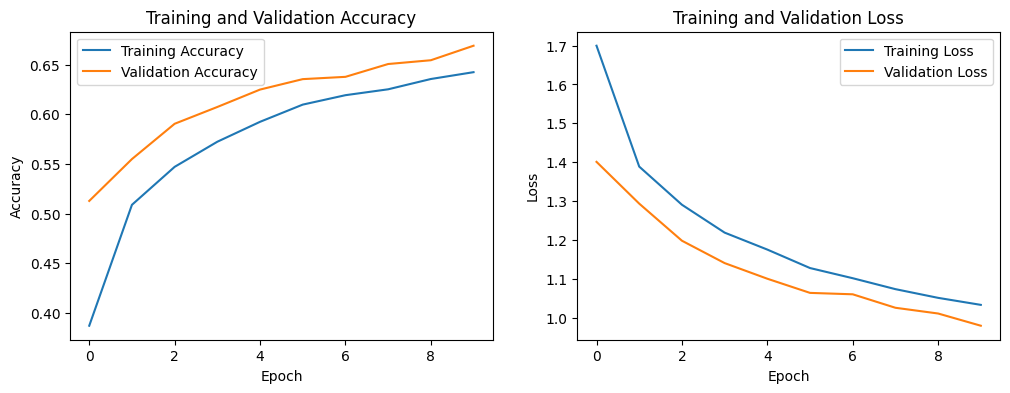

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


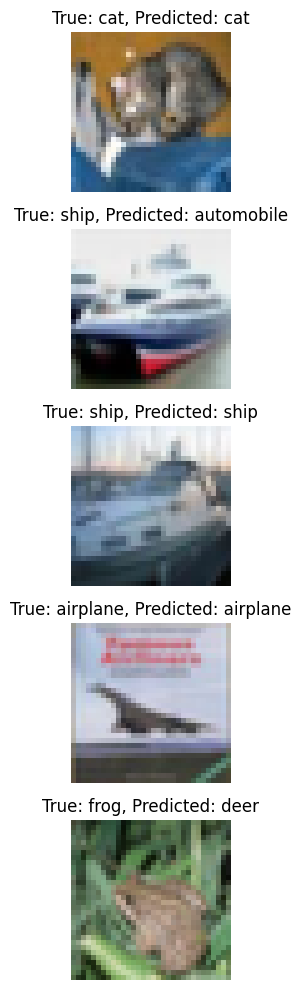

In [7]:
import matplotlib.pyplot as plt
import numpy as np

#Load the best model saved during training
model = keras.models.load_model(checkpoint_filepath)

# Compute accuracy on the test set.
print("\nEvaluating the best model on the test set...")
_, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Plot training & validation accuracy and loss curves.
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Show 5 example images with predicted classes.

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

predictions = model.predict(x_test)

plt.figure(figsize=(10, 10))
for i in range(5):
    plt.subplot(5, 1, i + 1)
    plt.imshow(x_test[i])
    predicted_class = np.argmax(predictions[i])
    true_class = y_test[i][0]
    plt.title(f"True: {class_names[true_class]}, Predicted: {class_names[predicted_class]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Observation & Improving Model Fitting & Generalization
Did the model overfit?
*No, at no point in training the model, did the model's validation accuracy diverge with its training accuracy nor did its validation loss diverge with it's training loss*

Try simple improvements:
Add padding to Conv2D layers (padding='same')
Change number of filters (32→64→128)
Increase epochs slightly
Record the best accuracy you achieve.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,738 (444.29 KB)

 Trainable params: 113,738 (444.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4209 - loss: 1.6006 - val_accuracy: 0.5648 - val_loss: 1.2598
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5631 - loss: 1.2280 - val_accuracy: 0.6133 - val_loss: 1.1090
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6177 - loss: 1.0821 - val_accuracy: 0.6711 - val_loss: 0.9545
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6574 - loss: 0.9835 - val_accuracy: 0.6822 - val_loss: 0.9105
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6787 - loss: 0.9172 - val_accuracy: 0.7089 - val_loss: 0.8369
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6988 - loss: 0.8613 - val_accuracy: 0.7224 - val_loss: 0.8000
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7169 - loss: 0.8155 - val_accuracy: 0.7366 - val_loss: 0.7832
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7252 - loss: 0.7828 - val_accuracy: 0.

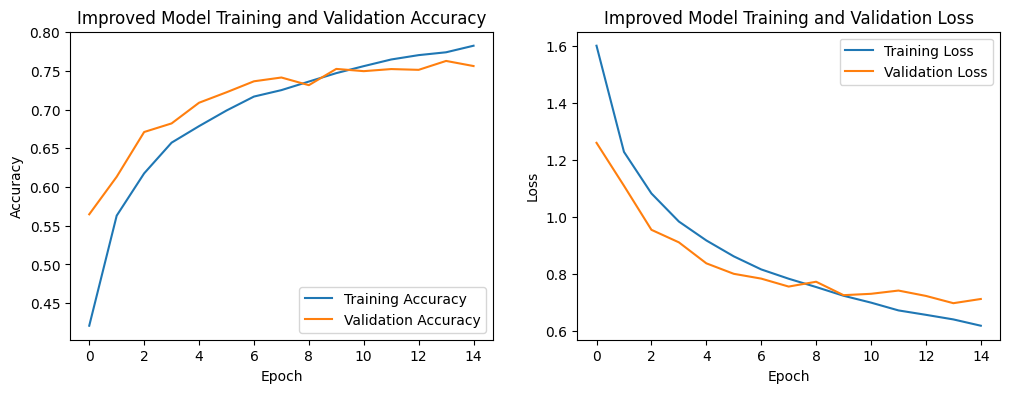

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


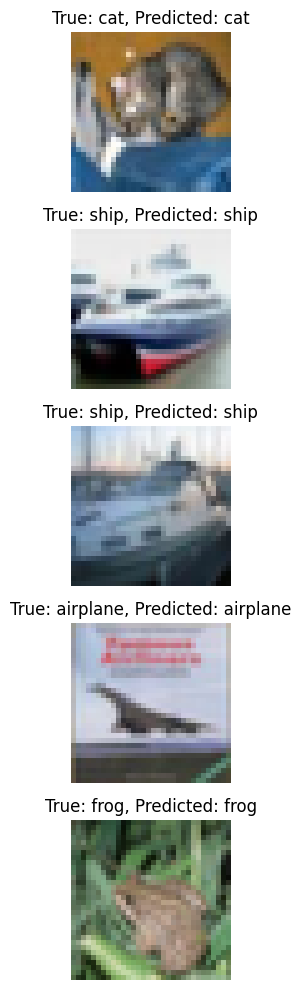

Best recorded improved model test accuracy: 0.7581


In [8]:
# Defines the checkpoint path for the improved model
checkpoint_filepath = 'best_model.keras'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

# New model with padding, one more Conv2D layer + one more MaxPooling2D block
model = keras.Sequential(
    [
        keras.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5), # Keep Dropout for regularization
        layers.Dense(10, activation="softmax"),
    ]
)

# Compiles the improved model
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# Displays improved model summary
model.summary()

# Trains for 15 epochs (increased slightly from 10)
history = model.fit(x_train, y_train,
                        epochs=15,
                        batch_size=64,
                        validation_split=0.2,
                        callbacks=[model_checkpoint_callback])

# Loads the best improved model saved during training
model = keras.models.load_model(checkpoint_filepath)

# Computes accuracy on the test set for the improved model
print("\nEvaluating the best improved model on the test set...")
_, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Improved Model Test Accuracy: {test_accuracy:.4f}")

# Plots training & validation accuracy and loss curves for the improved model
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Improved Model Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Improved Model Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Shows 5 example images with predicted classes for the improved model
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

predictions = model.predict(x_test)

plt.figure(figsize=(10, 10))
for i in range(5):
    plt.subplot(5, 1, i + 1)
    plt.imshow(x_test[i])
    predicted_class = np.argmax(predictions[i])
    true_class = y_test[i][0]
    plt.title(f"True: {class_names[true_class]}, Predicted: {class_names[predicted_class]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Best recorded improved model test accuracy: {test_accuracy:.4f}")

## Use a pretrained model
Use Xception (pretrained on ImageNet) for feature extraction:
Add a GlobalAveragePooling2D + Dense(10, softmax) on top.
Train the new model using ModelCheckpoint.
Evaluate accuracy, plot training curves, show 5 sample predictions.
Compare the CNN you built vs the pretrained Xception in terms of accuracy and training speed.


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 75, 75, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 3, 3, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,881,970 (79.66 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 66ms/step - accuracy: 0.6745 - loss: 1.0232 - val_accuracy: 0.7036 - val_loss: 0.9234
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 42ms/step - accuracy: 0.7344 - loss: 0.8261 - val_accuracy: 0.7226 - val_loss: 0.8659
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.7542 - loss: 0.7615 - val_accuracy: 0.7299 - val_loss: 0.8348
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.7656 - loss: 0.7224 - val_accuracy: 0.7330 - val_loss: 0.8150
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.7719 - loss: 0.6937 - val_accuracy: 0.7317 - val_loss: 0.8248
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.7795 - loss: 0.6678 - val_accuracy: 0.7298 - val_loss: 0.8247
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.7840 - loss: 0.6503 - val_accuracy: 0.7314 - val_loss: 0.8293
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.7892 - loss: 0.6340 - 

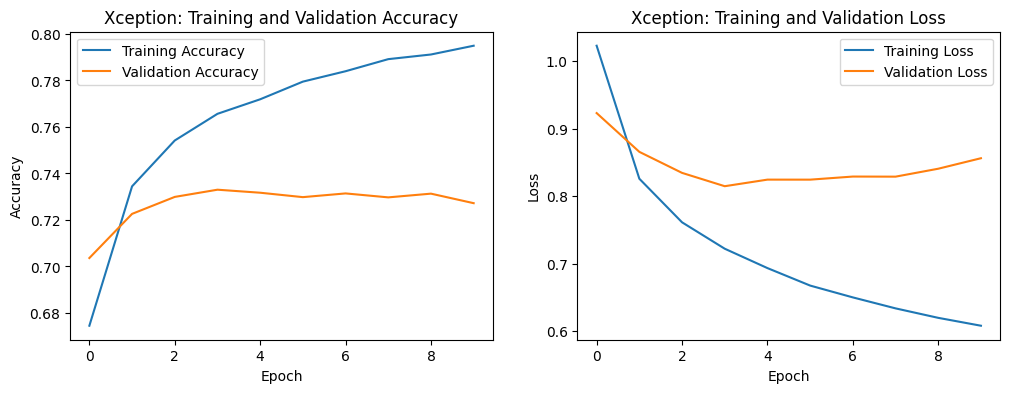

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step


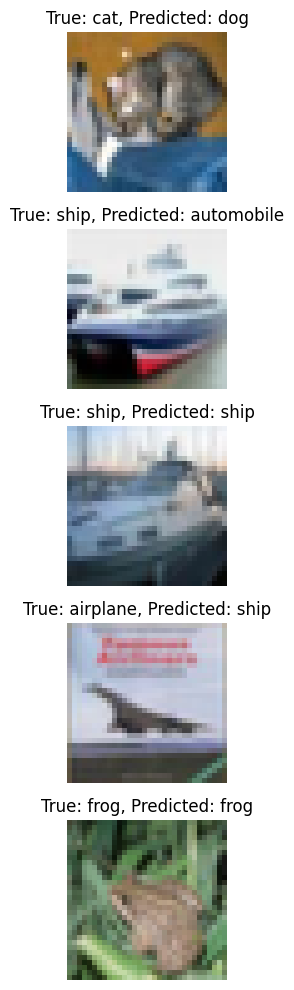


========== Model Comparison ==========
Basic CNN Test Accuracy:    0.6889
Improved CNN Test Accuracy: 0.7581
Xception Test Accuracy:     0.7309


In [9]:
from keras.applications import Xception

# Loads Xception pretrained on ImageNet, without the top classification layer
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(75, 75, 3)
)

# Freezes the base model
base_model.trainable = False

# Builds the full model: Xception base + custom classification head
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Resizing(75, 75)(inputs)
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
outputs = keras.layers.Dense(10, activation='softmax')(x)
xception_model = keras.Model(inputs, outputs)

# Compiling the Xception model
xception_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

xception_model.summary()

# ModelCheckpoint for Xception
xception_checkpoint = 'best_xception_model.keras'
xception_checkpoint_callback = ModelCheckpoint(
    filepath=xception_checkpoint,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
    )

# Trains Xception model with 10 epochs, batch size of 65, and validation split of 0.2
xception_history = xception_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[xception_checkpoint_callback]
    )

# Loads best checkpoint
xception_model = keras.models.load_model(xception_checkpoint)

# Evaluating the model on test set
_, xception_test_accuracy = xception_model.evaluate(x_test, y_test, verbose=0)
print(f"Xception Model Test Accuracy: {xception_test_accuracy:.4f}")

# Plots training & validation curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(xception_history.history['accuracy'], label='Training Accuracy')
plt.plot(xception_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Xception: Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(xception_history.history['loss'], label='Training Loss')
plt.plot(xception_history.history['val_loss'], label='Validation Loss')
plt.title('Xception: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Shows 5 example images with predictions
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

xception_preds = xception_model.predict(x_test)

plt.figure(figsize=(10, 10))
for i in range(5):
    plt.subplot(5, 1, i + 1)
    plt.imshow(x_test[i])
    predicted_class = np.argmax(xception_preds[i])
    true_class = y_test[i][0]
    plt.title(f"True: {class_names[true_class]}, Predicted: {class_names[predicted_class]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Comparison summary
print(f"Basic CNN Test Accuracy:    0.6889")
print(f"Improved CNN Test Accuracy: {test_accuracy:.4f}")
print(f"Xception Test Accuracy:     {xception_test_accuracy:.4f}")

## Part 2: Image Segmentation (Pascal VOC 2012)
**(1) Why can’t a standard CNN classifier architecture be directly used for segmentation?**

*A standard CNN classifier architecture can't be used directly for segmentation because classification and segmentation have different outputs. Classification involves labeling an image, utilizing flattening, global pooling, fully connected layers, and a one-output vector. Due to it being fully connected, CNN classifiers don't account for spatial details like where things are in an image. Segmentation involves associating pixels to a class (one class prediction per pixel) which requires resolution that isn't affected by pooling/downsampling, spatial structure awareness, and again, a one label vector as a final output instead of class-specific probabilities.*

**(2) What is the purpose of the encoder in an encoder–decoder segmentation model?**

*The purpose of the encoder in an encoder-decoder segmentation model is to extract and compress useful features from the input image. It applies convolution layers like pooling layers to detect features like edges and textures initially before building higher-level features like shapes, object parts, semantics. It also reduces the spatial size of the representation, creates smaller feature maps, and making it less computationally expensive*

**(3) What is the purpose of the decoder?**

*At a high level, the decoder takes the encoder's compressed feature representations (semantics, shapes, object parts) and then reconstructs it into a pixel-level prediction map (segmentation). Its main jobs are to upsample the low-resolution encoded features back to original image size, recover spatial detail, and then produce a class prediction for each pixel*

**(4) Why is Conv2DTranspose required in segmentation models?**

*Conv2DTranspose is the layer used in segmentation models that helps the decoder to restore the resolution from low-resolution features to original image size through learned upsampling (increasing height/width of feature maps). It also obviusly plays a role as a tool for rebuilding spatial recognition in doing so. It's a tool for the decoder.

**(5) Why is sparse categorical cross-entropy appropriate for this segmentation task?**

*Sparse categorical cross-entropy is appropriate here because there is pixel-wise multiclass classification. What this means is that we're dealing with multiple classes and each pixel is assigned to exactly one class via class ID) -- this is a problem that fits the profile of sparse categorical cross-entropy by design. Additionally, it matches softmax output since softmax provides per-pixel probabilities aross classes, and sparse categorical cross-entropy trains the model to put high probability on the correct class.*

## Data Set Preparation
Load the Pascal VOC 2012 dataset. https://www.kaggle.com/datasets/huanghanchina/pascal-voc-2012
Preprocess the images and segmentation masks:
Resize images and masks to 128×128 pixels.
Normalize the image pixel values to [0,1].
Ensure the mask labels are integer-encoded (0–20).
Split the dataset into training and validation sets.
Create TensorFlow datasets suitable for training: Batch the data, Prefetch for performance


In [10]:
import os
import tensorflow as tf
import kagglehub
from PIL import Image
from sklearn.model_selection import train_test_split

# Loads Pascal VOC 2012 Dataset
path = kagglehub.dataset_download("huanghanchina/pascal-voc-2012")
print("Dataset downloaded to:", path)

# Specified paths
VOC_ROOT = os.path.join(path, 'VOC2012')
IMAGES_DIR  = os.path.join(VOC_ROOT, 'JPEGImages')
MASKS_DIR   = os.path.join(VOC_ROOT, 'SegmentationClass')
SPLITS_DIR  = os.path.join(VOC_ROOT, 'ImageSets', 'Segmentation')

# Resizing of images and masks to 128 x 128
# Batch size of 32
# Validation split of 0.2
IMG_SIZE    = (128, 128)
BATCH_SIZE  = 32
VAL_SPLIT   = 0.2

# Scans for available segmentation filenames directly
filenames = [
    os.path.splitext(f)[0]
    for f in os.listdir(MASKS_DIR)
    if f.endswith('.png')
]

print(f"Total segmentation samples: {len(filenames)}")
# Loads and preprocesses a single image by normalizing to '/255'
def load_image(filename):
    path = os.path.join(IMAGES_DIR, filename + '.jpg')
    img = Image.open(path).convert('RGB')
    img = img.resize(IMG_SIZE, Image.BILINEAR)
    img = np.array(img, dtype=np.float32) / 255.0
    return img

# Loads and preprocesses a single mask
def load_mask(filename):
    path = os.path.join(MASKS_DIR, filename + '.png')
    mask = Image.open(path)
    mask = mask.resize(IMG_SIZE, Image.NEAREST)
    mask = np.array(mask, dtype=np.int32)
    mask[mask == 255] = 0
    mask = np.clip(mask, 0, 20)
    return mask

# Loads all images and masks into memory
images = np.array([load_image(f) for f in filenames], dtype=np.float32)
masks  = np.array([load_mask(f)  for f in filenames], dtype=np.int32)

print(f"Images shape: {images.shape}")
print(f"Masks  shape: {masks.shape}")
print(f"Mask value range: [{masks.min()}, {masks.max()}]")

# Train/Validation split
x_train, x_val, y_train, y_val = train_test_split(
    images, masks,
    test_size=VAL_SPLIT,
    random_state=42
)

print(f"\nTraining samples:   {len(x_train)}")
print(f"Validation samples: {len(x_val)}")

# Builds TensorFlow datasets
def make_dataset(images, masks, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((images, masks))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(images), seed=42)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_dataset = make_dataset(x_train, y_train, shuffle=True)
val_dataset   = make_dataset(x_val,   y_val,   shuffle=False)

print(f"\nTrain batches: {len(train_dataset)}")
print(f"Val batches: {len(val_dataset)}")


for img_batch, mask_batch in train_dataset.take(1):
    print(f"\nImage batch shape: {img_batch.shape}")
    print(f"Mask batch shape: {mask_batch.shape}")
    print(f"Image pixel range: [{img_batch.numpy().min():.2f}, {img_batch.numpy().max():.2f}]")
    print(f"Mask label range: [{mask_batch.numpy().min()}, {mask_batch.numpy().max()}]")

Using Colab cache for faster access to the 'pascal-voc-2012' dataset.
Dataset downloaded to: /kaggle/input/pascal-voc-2012
Total segmentation samples: 2913
Loading images and masks...
Images shape: (2913, 128, 128, 3)
Masks  shape: (2913, 128, 128)
Mask value range: [0, 20]

Training samples:   2330
Validation samples: 583

Train batches: 73
Val batches: 19

Image batch shape: (32, 128, 128, 3)
Mask batch shape: (32, 128, 128)
Image pixel range: [0.00, 1.00]
Mask label range: [0, 20]


## Build an Encoder–Decoder Model
Construct a fully convolutional network for segmentation.
Encoder: Use Conv2D layers with strides=2 to downsample (do not use MaxPooling Gradually increase the number of filters (e.g., 32 → 64 → 128 → 256).
Decoder: Use Conv2DTranspose layers to upsample. Gradually decrease the number of filters back to the number of classes.
Output layer: Use Conv2D with NUM_CLASSES filters and softmax activation.

In [11]:
# 20 object classes and 1 background class
NUM_CLASSES = 21

def build_segmentation_model(input_shape=(128, 128, 3), num_classes=NUM_CLASSES):

    inputs = keras.Input(shape=input_shape)

    # Normalizes pixel values inside the model by dividing by 255
    x = layers.Rescaling(1.0 / 255)(inputs)

    # Encoder portion of model
    # Conv to refine features, strides=2 for downsampling
    x = layers.Conv2D(32,  3, strides=2, activation="relu", padding="same")(x)   # 64x64
    x = layers.Conv2D(32,  3, activation="relu", padding="same")(x)

    x = layers.Conv2D(64,  3, strides=2, activation="relu", padding="same")(x)   # 32x32
    x = layers.Conv2D(64,  3, activation="relu", padding="same")(x)

    x = layers.Conv2D(128, 3, strides=2, activation="relu", padding="same")(x)   # 16x16
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)

    x = layers.Conv2D(256, 3, strides=2, activation="relu", padding="same")(x)   # 8x8
    x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)

    # Decoder portion of model
    # Conv to refine and Conv2DTranspose with strides=2 to upsample
    x = layers.Conv2DTranspose(256, 3, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(256, 3, strides=2, activation="relu", padding="same")(x)   # 16x16

    x = layers.Conv2DTranspose(128, 3, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(128, 3, strides=2, activation="relu", padding="same")(x)   # 32x32

    x = layers.Conv2DTranspose(64,  3, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(64,  3, strides=2, activation="relu", padding="same")(x)   # 64x64

    x = layers.Conv2DTranspose(32,  3, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(32,  3, strides=2, activation="relu", padding="same")(x)   # 128x128

    # Output of model
    outputs = layers.Conv2D(num_classes, 3, activation="softmax", padding="same")(x)

    return keras.Model(inputs, outputs, name="encoder_decoder_segmentation")


# Building the model
model = build_segmentation_model()
model.summary()

# IoU Metric
foreground_iou = keras.metrics.IoU(
    num_classes=NUM_CLASSES,
    target_class_ids=list(range(1, NUM_CLASSES)),
    name="foreground_iou",
    sparse_y_true=True,
    sparse_y_pred=False,
)

Model: "encoder_decoder_segmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 256)      │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 16, 16, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 32, 32, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 64, 64, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 128, 128, 32)   │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 128, 128, 21)   │         6,069 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,939,541 (11.21 MB)

 Trainable params: 2,939,541 (11.21 MB)

 Non-trainable params: 0 (0.00 B)

## Train the Model
Train your model for at least 15–20 epochs.
Use the training and validation datasets.
Optionally, add callbacks


In [12]:
# Compiling the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # masks are integer-encoded, not one-hot
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    # Save the best model based on val_accuracy
    ModelCheckpoint(
        filepath='best_segmentation_model.keras',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1)
]

# Training the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=callbacks
)

# Loads best saved model
model = keras.models.load_model('best_segmentation_model.keras')

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7282 - loss: 2.7713
Epoch 1: val_accuracy improved from None to 0.75102, saving model to best_segmentation_model.keras

Epoch 1: finished saving model to best_segmentation_model.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 38s 294ms/step - accuracy: 0.7422 - loss: 2.2023 - val_accuracy: 0.7510 - val_loss: 1.3447
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7464 - loss: 1.2871
Epoch 2: val_accuracy did not improve from 0.75102
73/73 ━━━━━━━━━━━━━━━━━━━━ 13s 70ms/step - accuracy: 0.7475 - loss: 1.2538 - val_accuracy: 0.7510 - val_loss: 1.2184
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7407 - loss: 1.2584
Epoch 3: val_accuracy did not improve from 0.75102
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.7475 - loss: 1.2260 - val_accuracy: 0.7510 - val_loss: 1.2195
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7467 - loss: 1.2282
Epoch 4: val_accuracy did not improve from

## Evaluate the Model
Compute pixel-wise accuracy on the validation dataset.
Predict segmentation masks for 3–5 validation images.
Visualize the results: Input image, True segmentation mask, Predicted mask


In [ ]:
# Pixel-level accuracy on full validation set
print("Evaluating on validation dataset...")
val_loss, val_accuracy = model.evaluate(val_dataset, verbose=1)
print(f"\nValidation Loss:     {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

# Predicting masks for 5 validation images
NUM_SAMPLES = 5

# Pulls one batch from validation set
sample_images, sample_masks = next(iter(val_dataset))
sample_images = sample_images[:NUM_SAMPLES]
sample_masks  = sample_masks[:NUM_SAMPLES]

# Prediction masks: output is (5, 128, 128, 21), argmax to get class per pixel
pred_masks = model.predict(sample_images)
pred_masks = np.argmax(pred_masks, axis=-1)

# VOC colormap for visualization
def voc_colormap(num_classes=21):
    "Returns the standard Pascal VOC color palette as an array (21, 3)"
    colormap = np.zeros((num_classes, 3), dtype=np.uint8)
    for i in range(num_classes):
        r, g, b, c = 0, 0, 0, i
        for j in range(8):
            r |= ((c >> 0) & 1) << (7 - j)
            g |= ((c >> 1) & 1) << (7 - j)
            b |= ((c >> 2) & 1) << (7 - j)
            c >>= 3
        colormap[i] = [r, g, b]
    return colormap

COLORMAP = voc_colormap()

def apply_colormap(mask):
    "Map integer label mask (H, W) to RGB image (H, W, 3)."
    return COLORMAP[mask]

# Visualizing the input, true mask, and predicted mask
fig, axes = plt.subplots(NUM_SAMPLES, 3, figsize=(12, NUM_SAMPLES * 3))

col_titles = ['Input Image', 'True Mask', 'Predicted Mask']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=13, fontweight='bold')

for i in range(NUM_SAMPLES):
    # Inputs image, denormalizing from [0,1] to [0,255]
    axes[i, 0].imshow(sample_images[i])
    axes[i, 0].axis('off')

    # True mask with VOC colors
    axes[i, 1].imshow(apply_colormap(sample_masks[i].numpy()))
    axes[i, 1].axis('off')

    # Predicted mask with VOC colors
    axes[i, 2].imshow(apply_colormap(pred_masks[i]))
    axes[i, 2].axis('off')

plt.suptitle('Segmentation Results', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# dPer-image accuracy breakdown
print("\nPer-image Pixel Accuracy:")
for i in range(NUM_SAMPLES):
    true  = sample_masks[i].numpy()
    pred  = pred_masks[i]
    acc   = np.mean(true == pred)
    print(f"  Image {i+1}: {acc*100:.2f}%")

#### Instructions

Add code cells and text cells as needed. If you need help programming in Colab Notebook, please see [Python Crash Course  Module 0. Setting up programming environment](https://colab.research.google.com/drive/1E_JhcV1G-uZbVpdESjbDcI7r3NkAUu6a?usp=sharing)

